# Problema de la mochila

bela gallardo ing fernandez

# Problema del agente viajero

Dado un grafo no dirigido y con pesos $G = (V, A)$ encontrar un ciclo simple de costo mínimo que pase por todos los nodos.

Características:
- Es un problema NP (No polinomial), pero necesitamos una solución eficiente.
Posibilidades:
1. **Los nodos son los candidatos**. Empezar en un nodo cualquiera. En cada paso moverse al nodo no visitado más próximo al último nodo seleccionado.


# Recocido simulado (simulated annealing)

- Hacer este problema para que podamos hacer que el intervalo sea de cierta profundidad de bits (no solo la normal)
- Hacer un análisis de sensibilización de parámetros.
Definir la función de temperatura para este algoritmo.

Consta de 2 cosas:
- Exploración (buscamos en todo el espacio)
- Explotación (si encontramos algo muy bueno, nos quedamos ahí)

Cómo escogemos la $T_{max}$?
Entre mas grandes sean los cambios de $\Delta E$ para la función objetivo, con esto podemos determinar le valor de la $T_{max}$, así que debemos ver cual es cambio y sacar un promedio y poner un valor parecido (en cantidad) a los cambios para evitar la convergencia prematura del algoritmo.


Definir el intervalo de búsqueda con cierta cantidad de bits, y además normalizar estos valores.

# Investigación:
- Funciones de De Jong para computo

In [6]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def decodificar_binario(bits, a, b):
    """
    Convierte una lista de bits a un valor real en el intervalo [a, b].
    """
    n = len(bits)
    # Convertir lista de bits a string y luego a entero decimal
    decimal = int("".join(str(bit) for bit in bits), 2)
    # Interpolar en el intervalo [a, b]
    return a + decimal * (b - a) / ((2**n) - 1)

def de_jong_1(x):
    """
    Función objetivo: Polinomio de De Jong 1 (Esfera) en 1D.
    f(x) = x^2
    """
    return -x**2

In [8]:
def Recocido_Binario(n_bits, a, b, func, minimizar=True, 
                     T_max=100.0, epsilon=0.01, tol=1e-4, 
                     tipo_temp='asintotica', alpha=0.1, iter_por_T=10):
    
    # Generar solución inicial aleatoria en formato binario
    s_actual_bits = [random.choice([0, 1]) for _ in range(n_bits)] # Creamos aleatoriamente un punto de inicio en binario
    s_actual_x = decodificar_binario(s_actual_bits, a, b)
    
    mejor_bits = list(s_actual_bits)
    mejor_x = s_actual_x
    
    T = T_max
    k = 1 # Contador de épocas para la temperatura asintótica
    
    # Historial para graficar
    historial_x = [s_actual_x]
    historial_y = [func(s_actual_x)]
    
    s_anterior_x = s_actual_x + tol * 10 # Evitamos que no se cumpla la tolerancia en la iteración 1
    
    # T > epsilon (temperatura minima) Y la diferencia entre soluciones es mayor a la Tolerancia
    while T > epsilon and abs(s_actual_x - s_anterior_x) >= tol:
        
        s_anterior_x = s_actual_x # Guardamos la solución de la época anterior
        
        # Evaluamos para una temperatura concreta que luego haremos descender
        for _ in range(iter_por_T):
            # Generar vecino cercano
            s_vecino_bits = list(s_actual_bits)
            idx = random.randint(0, n_bits - 1)
            s_vecino_bits[idx] = 1 - s_vecino_bits[idx] # Cambia 0 a 1, o 1 a 0
            
            s_vecino_x = decodificar_binario(s_vecino_bits, a, b)
            
            # Calcular delta E
            delta_E = func(s_vecino_x) - func(s_actual_x)
            
            # Si queremos maximizar, preguntamos y solo cambiamos el signo para evaluar el cambio
            if not minimizar:
                delta_E = -delta_E 
            
            # Como solo podemos aceptar si es deltaE <= 0 o la ec de Woltzman lo permite
            aceptado = False
            # Criterio de aceptación
            if delta_E <= 0:
                aceptado = True
                # Evaluar si es el mejor histórico
                if (minimizar and func(s_vecino_x) < func(mejor_x)) or \
                   (not minimizar and func(s_vecino_x) > func(mejor_x)): ## Aqui preguntamos si queremos minimo o máximo
                    mejor_bits = list(s_vecino_bits)
                    mejor_x = s_vecino_x
            else:
                probabilidad = math.exp(-delta_E / T)
                if random.random() < probabilidad:
                    aceptado = True
            
            # Si se acepta, el vecino se vuelve la solución actual
            if aceptado:
                s_actual_bits = list(s_vecino_bits)
                s_actual_x = s_vecino_x
                
        # Guardar solución de esta época para la gráfica
        historial_x.append(s_actual_x)
        historial_y.append(func(s_actual_x))
        
        # Actualización de Temperatura
        if tipo_temp == 'lineal':
            # T = T - alpha
            T = T - alpha
        elif tipo_temp == 'asintotica':
            T = T_max / (1 + alpha * k)
            
        k += 1 # Incrementar época

    # Graficando el mejor punto a cada descenso de temperatura
    x_vals = np.linspace(a, b, 500)
    y_vals = [func(x) for x in x_vals]
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, color='black', alpha=0.3, label='Función Objetivo F(x)')
    
    # Trazar el movimiento (trayectoria)
    plt.plot(historial_x, historial_y, color='green', marker='o', linestyle='-', alpha=0.7, label='Trayectoria del algoritmo')
    
    # Marcar inicio y fin
    plt.scatter(historial_x[0], historial_y[0], color='blue', s=100, zorder=5, label='Punto Inicial')
    plt.scatter(mejor_x, func(mejor_x), color='gold', edgecolors='black', s=200, zorder=5, marker='*', label='Mejor Solución Encontrada')
    
    plt.title(f'Optimización por Recocido Simulado Binario\nEnfriamiento: {tipo_temp.capitalize()} | Óptimo en x = {mejor_x:.4f}')
    plt.xlabel('Valor decodificado (x)')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return mejor_x, func(mejor_x), mejor_bits


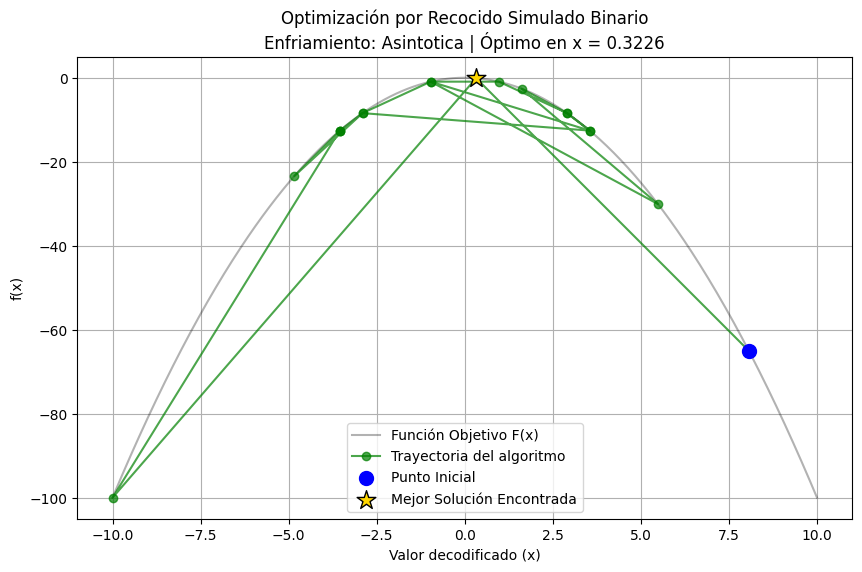


--- Resultados Finales ---
Mejor cadena binaria : [1, 0, 0, 0, 0]
Valor decodificado x : 0.322581
Mejor valor f(x)     : -0.104058


In [13]:
mejor_valor_x, mejor_f_x, cadena_binaria = Recocido_Binario(
    n_bits = 5,            # Longitud de la cadena binaria
    a = -10,              # Límite inferior (Estándar para De Jong)
    b = 10,               # Límite superior
    func = de_jong_1,       # Función a optimizar
    minimizar = False,       # True para Minimizar, False para Maximizar
    T_max = 200.0,          # Temperatura inicial
    epsilon = 0.001,        # Criterio de parada por enfriamiento (épsilon)
    tol = 1e-4,             # Criterio de parada por tolerancia de cambio
    tipo_temp = 'asintotica', # 'lineal' o 'asintotica'
    alpha = 0.5,            # Tasa de decaimiento
    iter_por_T = 15         # Vecinos evaluados por nivel de temperatura
)

print(f"\n--- Resultados Finales ---")
print(f"Mejor cadena binaria : {cadena_binaria}")
print(f"Valor decodificado x : {mejor_valor_x:.6f}")
print(f"Mejor valor f(x)     : {mejor_f_x:.6f}")

# Agregar la tabla como en la presentación

In [2]:
import math
import random
import pandas as pd

# ==========================================
# FUNCIONES AUXILIARES
# ==========================================

def decodificar_directo(bits):
    """Convierte la lista de bits directamente a un entero base 10."""
    return int("".join(str(bit) for bit in bits), 2)

def funcion_pdf(x):
    """
    Función objetivo del documento: f(x) = x^3 - 60x^2 + 900x + 100
    """
    return x**3 - 60*(x**2) + 900*x + 100

def formato_delta_f(delta):
    """Formatea la columna Delta f como en el PDF (<0 para mejoras)."""
    if delta < 0:
        return "<0"
    return str(int(delta))

# ==========================================
# ALGORITMO DE RECOCIDO SIMULADO (TABULAR)
# ==========================================

def Recocido_Tabular(bits_iniciales, T_inicial, alpha=0.9, iteraciones=8, movimientos_forzados=None):
    """
    Ejecuta el recocido simulado y guarda cada paso en una tabla.
    """
    # Configuración inicial
    s_actual_bits = [int(b) for b in bits_iniciales]
    T = float(T_inicial)
    
    # Lista para almacenar los registros de la tabla
    registros_tabla = []
    
    for i in range(iteraciones):
        # Decodificar y evaluar solución actual
        x_actual = decodificar_directo(s_actual_bits)
        f_actual = funcion_pdf(x_actual)
        
        # 1. Seleccionar el bit a cambiar (Move)
        if movimientos_forzados and i < len(movimientos_forzados):
            # Usar movimiento predeterminado (1-based index desde la izquierda)
            movimiento_idx = movimientos_forzados[i] - 1 
        else:
            # Aleatorio si no hay secuencia forzada
            movimiento_idx = random.randint(0, len(s_actual_bits) - 1)
            
        # 2. Generar el vecino (Solution)
        s_vecino_bits = list(s_actual_bits)
        s_vecino_bits[movimiento_idx] = 1 - s_vecino_bits[movimiento_idx] # Invertir bit
        
        # Decodificar y evaluar vecino
        x_vecino = decodificar_directo(s_vecino_bits)
        f_vecino = funcion_pdf(x_vecino)
        
        # 3. Calcular Delta f
        # Para maximizar y seguir la convención del PDF: Delta E = f(old) - f(new)
        delta_f = f_actual - f_vecino 
        
        # 4. Decisión de aceptación (Move?)
        aceptado = False
        if delta_f <= 0:
            aceptado = True
        else:
            probabilidad = math.exp(-delta_f / T)
            if random.random() <= probabilidad:
                aceptado = True
                
        # Guardar el registro para la tabla ANTES de actualizar la solución
        str_vecino = "".join(str(b) for b in s_vecino_bits)
        registros_tabla.append({
            "T": round(T, 1) if not T.is_integer() else int(T),
            "Move": movimiento_idx + 1, # Ajuste a base-1 para mostrar en tabla
            "Solution": str_vecino,
            "f": int(f_vecino),
            "Δf": formato_delta_f(delta_f),
            "Move?": "Yes" if aceptado else "No",
            "New Neighbor Solution": str_vecino if aceptado else "".join(str(b) for b in s_actual_bits)
        })
        
        # 5. Actualizar estados si fue aceptado
        if aceptado:
            s_actual_bits = list(s_vecino_bits)
            
        # 6. Actualizar Temperatura
        T = T * alpha

    # Retornar como un DataFrame de Pandas para visualización bonita
    return pd.DataFrame(registros_tabla)

# ==========================================
# REPLICANDO LAS TABLAS DEL DOCUMENTO
# ==========================================

# Secuencias exactas extraídas del documento
secuencia_escenario_1 = [1, 3, 5, 2, 4, 3, 4, 5, 1]
secuencia_escenario_2 = [1, 3, 5, 2, 4, 3]

print("=== Primer Escenario: T=500 y Solución Inicial (10011) ===")
tabla_1 = Recocido_Tabular(
    bits_iniciales="10011", 
    T_inicial=500.0, 
    iteraciones=8, 
    movimientos_forzados=secuencia_escenario_1
)
# Alineamos los strings a la izquierda y ocultamos el índice para que se vea igual al PDF
print(tabla_1.to_string(index=False)) 

print("\n\n=== Segundo Escenario: T=100 y Solución Inicial (10011) ===")
tabla_2 = Recocido_Tabular(
    bits_iniciales="10011", 
    T_inicial=100.0, 
    iteraciones=6, 
    movimientos_forzados=secuencia_escenario_2
)
print(tabla_2.to_string(index=False))

=== Primer Escenario: T=500 y Solución Inicial (10011) ===
    T  Move Solution    f   Δf Move? New Neighbor Solution
500.0     1    00011 2287  112   Yes                 00011
450.0     3    00111 3803   <0   Yes                 00111
405.0     5    00110 3556  247    No                 00111
364.5     2    01111 3475  328    No                 00111
328.1     4    00101 3225  578    No                 00111
295.2     3    00011 2287 1516    No                 00111
265.7     4    00101 3225  578    No                 00111
239.1     5    00110 3556  247    No                 00111


=== Segundo Escenario: T=100 y Solución Inicial (10011) ===
    T  Move Solution    f   Δf Move? New Neighbor Solution
100.0     1    00011 2287  112   Yes                 00011
 90.0     3    00111 3803   <0   Yes                 00111
 81.0     5    00110 3556  247    No                 00111
 72.9     2    01111 3475  328    No                 00111
 65.6     4    00101 3225  578    No                 